# Inspect the generalized U-Net heatmap prediction

This notebook loads the generalized model's `best_UNet.pt` when available, otherwise `latest_UNet.pt`, and displays:

1. The RGB camera observation.
2. The model's predicted heatmap probability.
3. The environment's ground-truth heatmap.
4. The prediction overlaid on the RGB observation.

It runs in evaluation mode with gradients disabled and does not modify the saved training seed or iteration.

In [218]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


def find_environment_directory():
    current_directory = Path.cwd().resolve()
    candidates = [
        current_directory,
        current_directory / "CODE" / "Enviornment",
        *current_directory.parents,
    ]
    for candidate in candidates:
        if (
            (candidate / "enviornment.py").is_file()
            and (candidate / "Model").is_dir()
            and (candidate / "xml_models" / "world.xml").is_file()
        ):
            return candidate
    raise RuntimeError("Could not find CODE/Enviornment from the current notebook directory")


ENVIRONMENT_DIRECTORY = find_environment_directory()
if str(ENVIRONMENT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(ENVIRONMENT_DIRECTORY))

from Model.UNet.unet import UNet
from Model.UNet.tmp.UNET_MODEL_OVERFIT_2ND_ROUND.UNetV2Constants import UNetV2Constants
from enviornment import Enviornment
from enviornment_randomizer import Enviornment_Randomizer
from randomization_constants import Randomization_Constants

WORLD_XML_FILE = ENVIRONMENT_DIRECTORY / "xml_models" / "world.xml"
CHECKPOINT_DIRECTORY = ENVIRONMENT_DIRECTORY / "Model" / "UNet" / "tmp" / "General_Attempt_Using_2nd_Overfit"
BEST_CHECKPOINT_FILE = CHECKPOINT_DIRECTORY / "best_UNet.pt"
LATEST_CHECKPOINT_FILE = CHECKPOINT_DIRECTORY / "latest_UNet.pt"
CHECKPOINT_FILE = BEST_CHECKPOINT_FILE if BEST_CHECKPOINT_FILE.is_file() else LATEST_CHECKPOINT_FILE
LAST_TRAINED_SEED_FILE = CHECKPOINT_DIRECTORY / "last_seed.txt"

print(f"Environment directory: {ENVIRONMENT_DIRECTORY}")
print(f"Checkpoint: {CHECKPOINT_FILE}")

Environment directory: /Users/aadibhatia/self-feeder-env/CODE/Enviornment
Checkpoint: /Users/aadibhatia/self-feeder-env/CODE/Enviornment/Model/UNet/tmp/General_Attempt_Using_2nd_Overfit/best_UNet.pt


In [219]:
if not CHECKPOINT_FILE.is_file():
    raise RuntimeError(
        f"Checkpoint not found: {CHECKPOINT_FILE}\n"
        "Run the generalized trainer until latest_UNet.pt or best_UNet.pt is created."
    )

model_constants = UNetV2Constants()
randomization_constants = Randomization_Constants()
enviornment_randomizer = Enviornment_Randomizer()

env = Enviornment(
    xml_file=str(WORLD_XML_FILE),
    Enviornment_Randomizer=enviornment_randomizer,
    Randomization_Constants=randomization_constants,
    Model_Constants=model_constants,
)

model = UNet(
    in_channels=3,
    num_classes=1,
    checkpoint_dir=str(CHECKPOINT_DIRECTORY),
    learning_rate=model_constants.learning_rate,
)
model.load_state_dict(
    torch.load(CHECKPOINT_FILE, map_location=model.device, weights_only=True)
)
model.eval()

print(f"Loaded checkpoint on: {model.device}")

Created UNet on: mps
Loaded checkpoint on: mps


In [220]:
def predict_scene(seed):
    env.new_scene(seed=seed)
    rgb_observation = env.observation()
    target_heatmap = env.get_target_heatmap()

    model_input = torch.from_numpy(rgb_observation).permute(2, 0, 1).unsqueeze(0).float()
    model_input = model_input / 255.0
    model_input = F.interpolate(
        model_input,
        size=(model_constants.input_y_dim, model_constants.input_x_dim),
        mode="bilinear",
        align_corners=False,
    )
    model_input = model_input.to(model.device)

    with torch.no_grad():
        prediction_logits = model(model_input)
        predicted_heatmap = torch.sigmoid(prediction_logits)[0, 0].cpu().numpy()

    return rgb_observation, predicted_heatmap, target_heatmap


In [ ]:
# Test well beyond the last seed used for generalized training.
last_trained_seed = int(LAST_TRAINED_SEED_FILE.read_text().strip())
TEST_SEED = last_trained_seed + 1_000_000 +np.random.randint(1, 1012)
rgb_observation, predicted_heatmap, target_heatmap = predict_scene(TEST_SEED)

predicted_peak_y, predicted_peak_x = np.unravel_index(
    np.argmax(predicted_heatmap),
    predicted_heatmap.shape,
)
target_peak_y, target_peak_x = np.unravel_index(
    np.argmax(target_heatmap),
    target_heatmap.shape,
)

print(f"Test seed: {TEST_SEED}")
print(f"RGB shape: {rgb_observation.shape}")
print(f"Prediction shape: {predicted_heatmap.shape}")
print(f"Target shape: {target_heatmap.shape}")
print(f"Prediction range: {predicted_heatmap.min():.6f} to {predicted_heatmap.max():.6f}")
print(f"Target range: {target_heatmap.min():.6f} to {target_heatmap.max():.6f}")
print(f"Strongest predicted pixel (x, y): ({predicted_peak_x}, {predicted_peak_y})")
print(f"Strongest target pixel (x, y): ({target_peak_x}, {target_peak_y})")

Test seed: 1007999
RGB shape: (1080, 1920, 3)
Prediction shape: (144, 256)
Target shape: (144, 256)
Prediction range: 0.000000 to 0.495954
Target range: 0.000000 to 1.000000
Strongest predicted pixel (x, y): (222, 94)
Strongest target pixel (x, y): (221, 92)


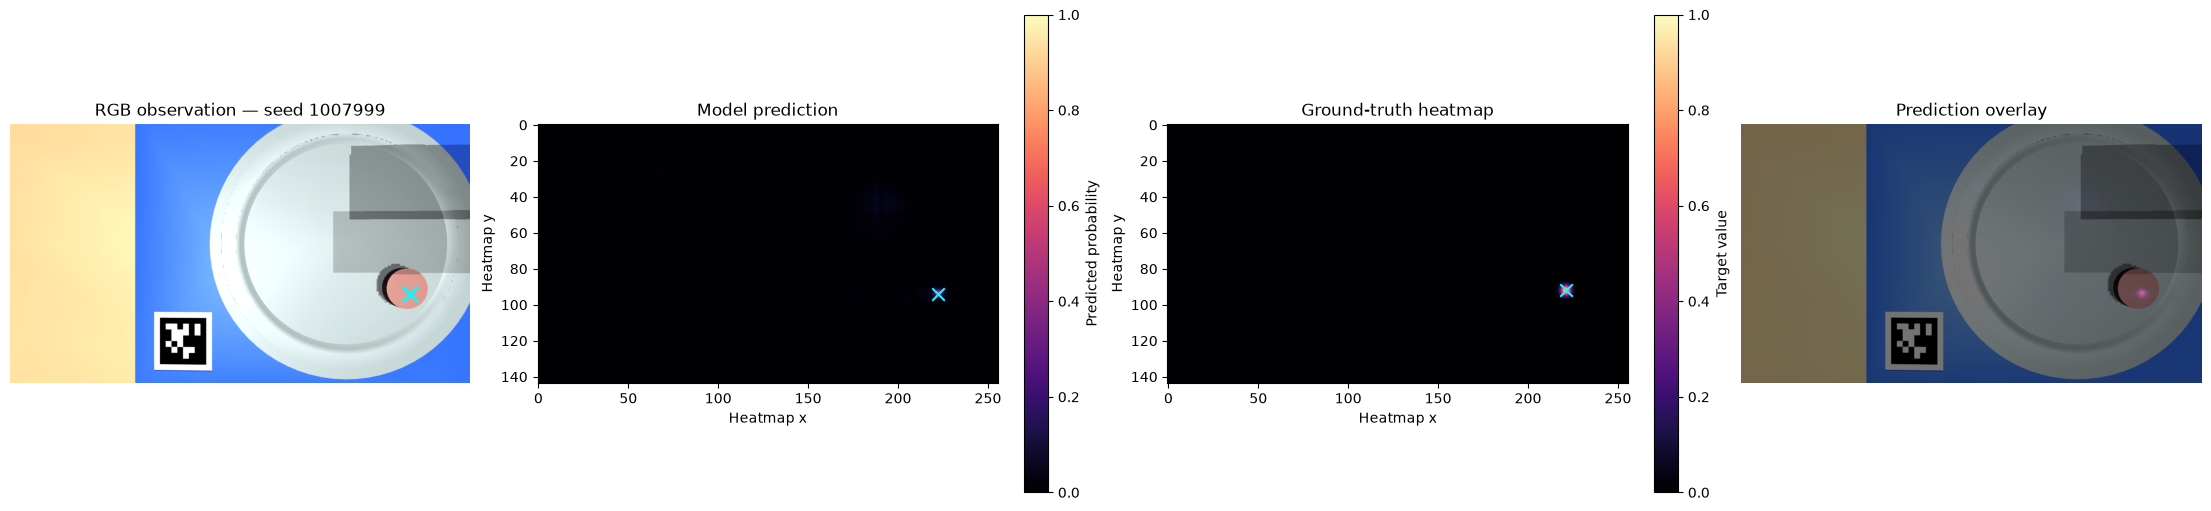

In [222]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)

observation_height, observation_width = rgb_observation.shape[:2]
heatmap_height, heatmap_width = predicted_heatmap.shape
predicted_peak_rgb_x = (predicted_peak_x + 0.5) * observation_width / heatmap_width
predicted_peak_rgb_y = (predicted_peak_y + 0.5) * observation_height / heatmap_height

axes[0].imshow(rgb_observation)
axes[0].scatter(
    predicted_peak_rgb_x,
    predicted_peak_rgb_y,
    c="cyan",
    marker="x",
    s=120,
    linewidths=2,
)
axes[0].set_title(f"RGB observation — seed {TEST_SEED}")
axes[0].axis("off")

prediction_image = axes[1].imshow(
    predicted_heatmap,
    cmap="magma",
    vmin=0.0,
    vmax=1.0,
    origin="upper",
)
axes[1].scatter(predicted_peak_x, predicted_peak_y, c="cyan", marker="x", s=80)
axes[1].set_title("Model prediction")
axes[1].set_xlabel("Heatmap x")
axes[1].set_ylabel("Heatmap y")
fig.colorbar(prediction_image, ax=axes[1], label="Predicted probability")

target_image = axes[2].imshow(
    target_heatmap,
    cmap="magma",
    vmin=0.0,
    vmax=1.0,
    origin="upper",
)
axes[2].scatter(target_peak_x, target_peak_y, c="cyan", marker="x", s=80)
axes[2].set_title("Ground-truth heatmap")
axes[2].set_xlabel("Heatmap x")
axes[2].set_ylabel("Heatmap y")
fig.colorbar(target_image, ax=axes[2], label="Target value")

axes[3].imshow(rgb_observation)
axes[3].imshow(
    predicted_heatmap,
    cmap="magma",
    alpha=0.55,
    vmin=0.0,
    vmax=1.0,
    origin="upper",
    extent=(0, observation_width, observation_height, 0),
)
axes[3].set_title("Prediction overlay")
axes[3].axis("off")

plt.show()

## Try another scene

Change `TEST_SEED` to inspect another deterministic scene and rerun the final two cells. Keep it above `last_trained_seed` when you want an unseen scene. The notebook does not modify the generalized trainer's seed or iteration files.